In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from tqdm import tqdm

In [3]:
#DEFINE SCALING RELATION
    
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772
    
#DEFINE SLIDING AUTOCORRELATION
    
def sliding_acf_search(frequency, #frequency array
                       power_flat, #flattened power spectrum
                       numax_grid, #array of values of nu_max to run autocorrelation around
                       k_width=4.0, #width of each window as a multiple of delta_nu
                       lag_frac=(0.8, 1.2) 
                      ):
    
    acf_strength = []
    
    for nu_c in numax_grid:
    
        #use scaling relation to get estimated delta_nu for each nu_max
        dnu = delta_nu_from_numax(nu_c)
    
        #window width
        W = k_width * dnu

            
        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue
    
        # Local, whitened spectrum
        p = power_flat[mask]
        p = p / np.median(p)
    
        # Autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:]
    
        # Lag axis
        df = frequency[1] - frequency[0]
        lag = np.arange(acf.size) * df
    
        # Measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])
    
        acf_strength.append(strength)
    
    return np.array(acf_strength)

#DEFINE MASK AROUND DELTA_NU_EST PEAK

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac):
        #justify the choices of window_frac = 0.2, mask boundaries
    
        # Central window around delta_nu
        main_lo = delta_nu_est * (1 - window_frac)
        main_hi = delta_nu_est * (1 + window_frac)
    
        mask = (
            (lags > main_lo) & (lags < main_hi)
        )
    
        return lags[mask], acf[mask]

#FUNCTIONS FOR GENERATING NOISE

def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_lvl):
    # freqs: list of frequencies of the data
    # N: number of different fake signals
    # Noise_low/high: lower and upper bounds of the whitenoise level
    signals= []
    for i in tqdm(range(0,N)):
        fake_base=[noise_lvl]*len(freqs)
        fake_signal=random(fake_base)
        signals.append(fake_signal)
    return np.array(signals)

#DEFINE GAUSSIAN

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c

In [5]:
def find_metric(power, freq):
    #SMOOTHING
        
    df = np.median(np.diff(freq))  # µHz
    smooth_width_muHz = 500    #justify smoothing choice - larger scales than delta_nu
    smooth_width_bins = int(smooth_width_muHz / df)
    background = uniform_filter1d(power, size =smooth_width_bins)
    power_flat = power / background
        
    #CALL SLIDING AUTOCORRELATOR, GET NU_MAX_METRIC
        
    numax_grid = np.linspace(50, nu_nyq, 1000)   #should run up to nyquist frequency
        
    acf_power = sliding_acf_search(
        freq,
        power_flat,
        numax_grid,
        k_width=4.0
    )
    nu_max_peak = np.max(acf_power)
    baseline1 = np.median(acf_power)
    scatter1 = np.std(acf_power)
    nu_max_metric = (nu_max_peak - baseline1) / scatter1
    
    numax_est = numax_grid[np.argmax(acf_power)]
        
    #RUN AUTOCORRELATION AROUND DELTA_NU_EST
        
    delta_nu_est = delta_nu_from_numax(numax_est)
    width = 4* delta_nu_est
    mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
    freq_window = freq[mask]
    power_window = power_flat[mask]
        
    acf_full = np.correlate(power_window, power_window, mode="full")
    N = len(power_window)
    acf = acf_full[N-1:]
    lags_bins = np.arange(len(acf))
    lags_muHz = lags_bins * df
    acf /= acf[0]
        
    #FIND ACF MAX WITHIN MASK, GIVING DELTA_NU_METRIC
        
    lags_fit, acf_fit = mask_acf_for_deltanu(
        lags_muHz,
        acf,
        delta_nu_est,
        window_frac=0.2
    )
    peak2 = np.max(acf_fit)
    baseline2 = np.median(acf_fit)
    scatter2 = np.std(acf_fit)
    
    delta_nu_metric = (peak2 - baseline2)/scatter2
    
    return nu_max_metric, delta_nu_metric, lags_fit, acf_fit, delta_nu_est, acf_power

In [7]:
def final_fit(lags_fit, acf_fit, delta_nu_est, acf_power):
    if len(acf_fit) < 5 or np.all(acf_fit == acf_fit[0]):
        delta_nu_metric = np.nan
        delta_nu_fit = delta_nu_est
        delta_nu_err = np.nan
    else:
        peak = np.max(acf_fit)
        baseline2 = np.median(acf_fit)
        scatter2 = np.std(acf_fit)
        delta_nu_metric = (peak - baseline2)/scatter2

        # ---- Gaussian fit to Δν ----
        p0 = [peak, delta_nu_est, 0.2*delta_nu_est, baseline2]
        bounds = ([0, 0.5*delta_nu_est, 0.01*delta_nu_est, -np.inf],
                  [np.inf, 1.5*delta_nu_est, 1.0*delta_nu_est, np.inf])
        try:
            popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds, maxfev=5000)
            delta_nu_fit = popt[1]
            delta_nu_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            delta_nu_fit = delta_nu_est
            delta_nu_err = np.nan

    df = np.median(np.diff(freq))

    smooth_env_bins = int(1.5 * delta_nu_fit / df)
    envelope = uniform_filter1d(acf_power, size=smooth_env_bins)
    
    numax_grid = np.linspace(50, nu_nyq, 1000)
    numax_est = numax_grid[np.argmax(acf_power)]
    
    mask_env = (numax_grid > numax_est - 5*delta_nu_fit) & (numax_grid < numax_est + 5*delta_nu_fit)
    if np.any(mask_env):
        p0 = [acf_power[mask_env].max(), numax_est, 2*delta_nu_fit, 1]
        try:
            popt, pcov = curve_fit(gaussian, numax_grid[mask_env], acf_power[mask_env], p0=p0, maxfev=5000)
            nu_max_fit = popt[1]
            nu_max_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            nu_max_fit = numax_est
            nu_max_err = np.nan
    else:
        nu_max_fit = numax_est
        nu_max_err = np.nan
            
    return delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err

def find_noise_lvl(power, nu_max_fit, nu_max_err):
    nu_start = nu_max_fit + 3*nu_max_err
    nu_end = freq.max()
    mask = (freq >= nu_start) & (freq <= nu_end)
    noise_lvl = np.median(power[mask]) / np.log(2)
    return noise_lvl

In [9]:
delta_t = 58.9 #for PLATO, 25s
nu_nyq = 1/(2*delta_t) * 10**(6)
#nu_nyq = 3000
print(f"Nyquist frequency: {nu_nyq:.2f}")

T = 30*24*60*60 #30 days
N = int(T/(2*delta_t))
#N = 7775
print(f"Number of data points: {N}")

Nyquist frequency: 8488.96
Number of data points: 22003


In [11]:
import glob
import os

# Folder containing your .pow files
data_folder = r"C:\Users\douga\Documents\Asteroseismology\Kepler30daypowerspectra"

# Find all .pow files
pow_files = glob.glob(os.path.join(data_folder, "*.pow"))

# Prepare lists to store results
nu_max_metrics_kepler = []
delta_nu_metrics_kepler = []
combined_metrics_kepler = []

delta_nu_fits = []
delta_nu_errs = []
nu_max_fits = []
nu_max_errs = []

noise_lvls = []
# Loop over all files
for f in tqdm(pow_files):
    # Load frequency and power
    data = np.loadtxt(f)
    freq = data[:, 0]
    power = data[:, 1]
    
    # Compute your metrics
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq)
    
    # Store results
    nu_max_metrics_kepler.append(nu_max)
    delta_nu_metrics_kepler.append(delta_nu)
    combined_metrics_kepler.append(nu_max * delta_nu)

    delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err = final_fit(lags_fit, acf_fit, delta_nu_est, acf_power)
    
    delta_nu_fits.append(delta_nu_fit)
    delta_nu_errs.append(delta_nu_err)
    nu_max_fits.append(nu_max_fit)
    nu_max_errs.append(nu_max_err)

    noise_lvl = find_noise_lvl(power, nu_max_fit, nu_max_err)

    noise_lvls.append(noise_lvl)    

# Convert to NumPy arrays for convenience
nu_max_metrics_kepler = np.array(nu_max_metrics_kepler, dtype=float)
delta_nu_metrics_kepler = np.array(delta_nu_metrics_kepler, dtype=float)
combined_metrics_kepler = np.array(combined_metrics_kepler, dtype=float)
delta_nu_fits = np.array(delta_nu_fits)
delta_nu_errs = np.array(delta_nu_errs)
nu_max_fits = np.array(nu_max_fits)
nu_max_errs = np.array(nu_max_errs)

print("Nu_max metrics:", nu_max_metrics_kepler)
print("Delta_nu metrics:", delta_nu_metrics_kepler)
print("Combined metrics:", combined_metrics_kepler)
print("Delta_nu:", delta_nu_fits)
print("Delta_nu errors:", delta_nu_errs)
print("Nu_max:", nu_max_fits)
print("Nu_max errors:", nu_max_errs)
print("Noise levels:", noise_lvls)

100%|██████████| 3/3 [00:02<00:00,  1.13it/s]

Nu_max metrics: [5.1094023  4.45836789 3.98371952]
Delta_nu metrics: [3.19637936 5.57085006 2.76899537]
Combined metrics: [16.33158802 24.83689906 11.03090092]
Delta_nu: [ 88.13611196 139.6060717   52.77816171]
Delta_nu errors: [0.2550229  2.23510479 0.23724205]
Nu_max: [1897.64228063 3580.56700997 1023.76889688]
Nu_max errors: [3.44465737 5.95756564 3.53078793]
Noise levels: [np.float64(1.0535630534544773), np.float64(0.2873582225921976), np.float64(4.1526394291463085)]


In [15]:
freq_noise=np.linspace(0,nu_nyq,N)
powers_noise=fake_signals(freq_noise,1000,noise_lvls[1])

100%|██████████| 1000/1000 [01:10<00:00, 14.20it/s]


In [17]:
nu_max_metrics_noise = []
delta_nu_metrics_noise = []
combined_metrics_noise = []
for power in tqdm(powers_noise):
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)

    nu_max_metrics_noise.append(nu_max)
    delta_nu_metrics_noise.append(delta_nu)
    combined_metrics_noise.append(nu_max * delta_nu)

nu_max_metrics_noise = np.array(nu_max_metrics_noise)
delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
combined_metrics_noise = np.array(combined_metrics_noise)

100%|██████████| 1000/1000 [12:55<00:00,  1.29it/s]


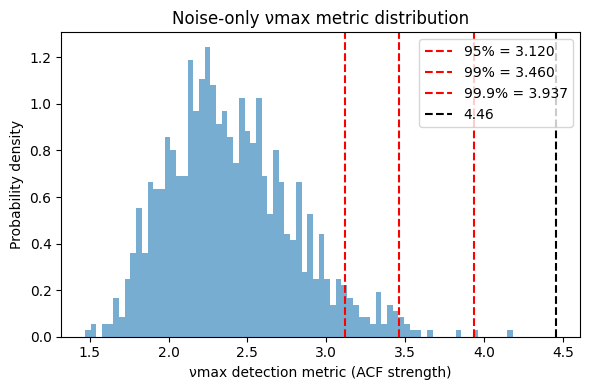

In [31]:
plt.figure(figsize=(6,4))
plt.hist(nu_max_metrics_noise, bins=75, density=True, alpha = 0.6)

for p in [95, 99, 99.9]:
    thr = np.percentile(nu_max_metrics_noise, p)
    plt.axvline(thr, linestyle="--", label=f"{p}% = {thr:.3f}", color = "r")
#for nu_max in nu_max_metrics_kepler:
plt.axvline(nu_max_metrics_kepler[1], linestyle = "--", label = f"{nu_max_metrics_kepler[1]:.2f}", color = "k")
plt.xlabel("νmax detection metric (ACF strength)")
plt.ylabel("Probability density")
plt.title("Noise-only νmax metric distribution")
plt.legend()
plt.tight_layout()
plt.savefig("vmax_hist1.png", dpi = 600, bbox_inches = "tight")
plt.show()

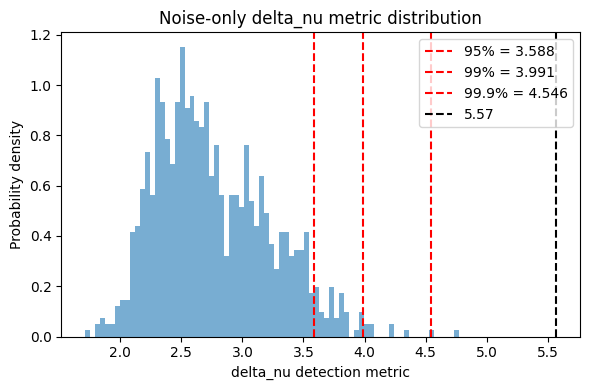

In [29]:
plt.figure(figsize=(6,4))
plt.hist(delta_nu_metrics_noise, bins=75, density=True, alpha = 0.6)

for p in [95, 99, 99.9]:
    thr = np.percentile(delta_nu_metrics_noise, p)
    plt.axvline(thr, linestyle="--", label=f"{p}% = {thr:.3f}", color = "r")
#for delta_nu in delta_nu_metrics_kepler:
plt.axvline(delta_nu_metrics_kepler[1], linestyle = "--", label = f"{delta_nu_metrics_kepler[1]:.2f}", color = "k")
plt.xlabel("delta_nu detection metric")
plt.ylabel("Probability density")
plt.title("Noise-only delta_nu metric distribution")
plt.legend()
plt.tight_layout()
plt.savefig("deltav_hist1.png", dpi = 600, bbox_inches = "tight")
plt.show()

In [23]:
combined_metrics_noise = np.array(nu_max_metrics_noise) * np.array(delta_nu_metrics_noise)

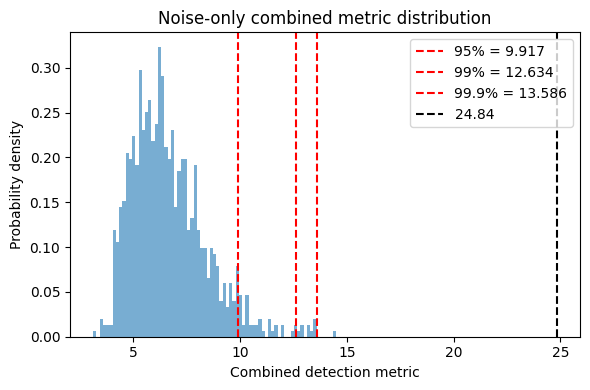

In [27]:
plt.figure(figsize=(6,4))
plt.hist(combined_metrics_noise, bins=75, density=True, alpha = 0.6)

for p in [95, 99, 99.9]:
    thr = np.percentile(combined_metrics_noise, p)
    plt.axvline(thr, linestyle="--", label=f"{p}% = {thr:.3f}", color = "r")
#for combined in combined_metrics_kepler:
plt.axvline(combined_metrics_kepler[1], linestyle = "--", label = f"{combined_metrics_kepler[1]:.2f}", color = "k")
plt.xlabel("Combined detection metric")
plt.ylabel("Probability density")
plt.title("Noise-only combined metric distribution")
plt.legend()
plt.tight_layout()
plt.savefig("combined_hist1.png", dpi = 600, bbox_inches = "tight")
plt.show()